In [7]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

In [10]:
# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.639511201629328
Precision: 0.635139845562833
Recall: 0.6380026990553306
Macro F1: 0.6356107342023884
Log Loss 1.4252414617944464
[[50  0  3  5  6  1  6  4]
 [ 0 58  2  0  3  2 10  0]
 [ 5  2 23  0  1  2  2  4]
 [ 9  2  1 45  5  0  9  4]
 [ 8  2  1  8 46  4  5  1]
 [ 0  2  0  1  2 28  4  1]
 [ 1 14  4  7  1  5 42  1]
 [ 1  3  6  3  3  0  1 22]]


This model does have some success in classification, as its macro f1 is better than random chance (0.5)! Though, it's still not great. A value of 0.638 basically just means that the model is having *some* success. We can see that some particular features in particular are difficult to classify, like c2r7 or c7r2. Seeing as they have the same indexes, just with r and c swapped, they're two sides of the same coin. One represents False Negatives, the other True Negatives, so clearly this class is both identified to be another class more often and more often isn't identified when it's the actual class.

Log loss for 8 classifications would give a value around 2.079 if the model was guessing at complete random. This means the model is actually improving prediction, though not a whole lot. Preferrably this value would be closer to 0.

In [ ]:
# minilearn
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import LogisticRegression

# Predicting emotion from features

X = features.copy()
y = df["emotion_code"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = LogisticRegression(learning_rate=1, max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.639511201629328
Precision: 0.6374611892265585
Recall: 0.6394013163924137
Macro F1: 0.6330699017905317
pred   1   2   3   4   5   6   7   8
true                                
1     19   0   1   5   1   0   2   1
2      2  56   3   6   0   0   4   0
3      0   6  50   2   2   3   2   2
4      3   6   9  47   1   5   2   0
5      0   0   8   0  52  12   3   4
6      2   1  13  12  12  38   1   4
7      1   4   1   1   4   3  23   4
8      3   0   5   2   1   4   4  29


Minilearn is performing almost identically to sklearn. Here, we can see lots of misclassifications with feature 6 in particular.

In [ ]:
# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# Predicting gender from features

X = features.copy()
y = df["actor_gender"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9918533604887984
Precision: 0.9919555688384141
Recall: 0.9917759336099585
Macro F1: 0.9918492695883134
Log Loss 0.016464854502058424
[[238   3]
 [  1 249]]


The model is nearly perfect at classifying the gender of an actor!

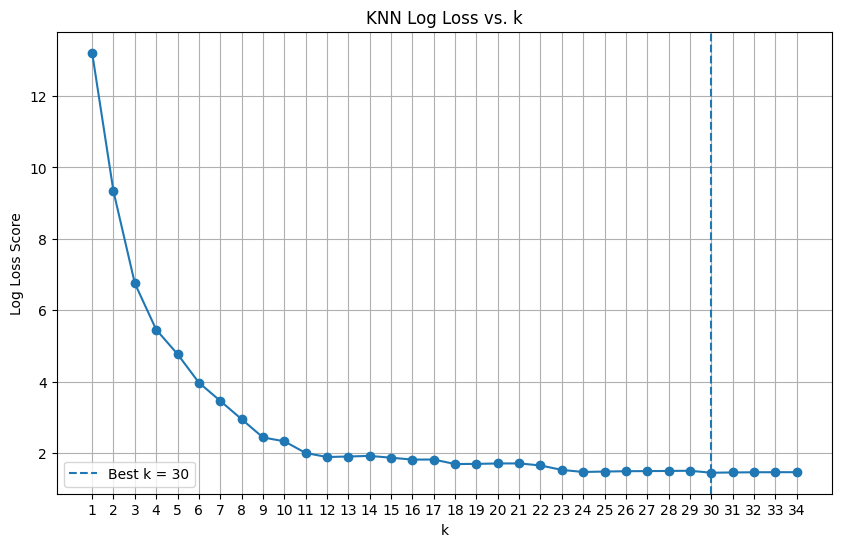

Best k: 30
Best Log Loss: 1.4537


In [ ]:
# sklearn
from sklearn.neighbors import KNeighborsClassifier

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different k values
k_values = range(1, 35)
log_loss_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict_proba(X_test_scaled)

    log_loss_scores.append(log_loss(y_test, y_proba))

# Find best k
best_log_loss = min(log_loss_scores)
best_k = k_values[log_loss_scores.index(best_log_loss)]

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, log_loss_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("Log Loss Score")
plt.title("KNN Log Loss vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best Log Loss: {best_log_loss:.4f}")

According to log_loss, 30 is the optimal k value to use for this data. Still, not too much better than random. I'll compare to F1.

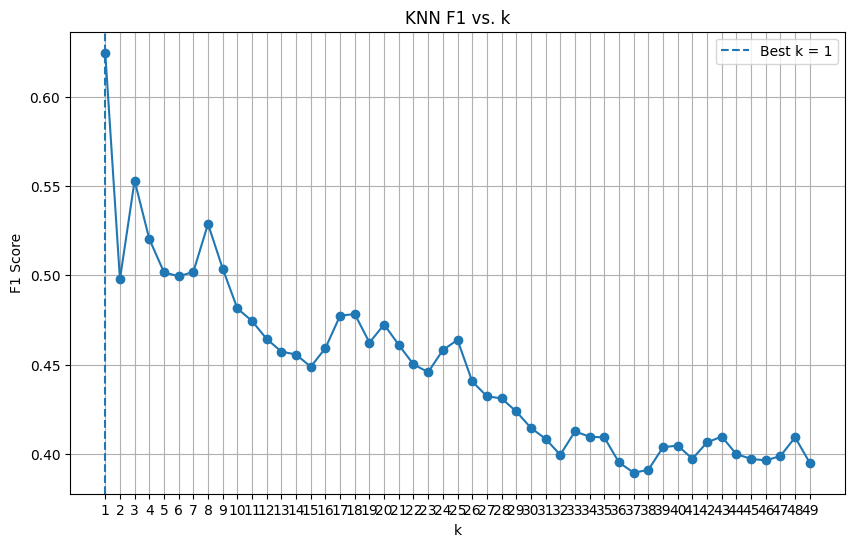

Best k: 1
Best f1_score: 0.6245


In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different k values
k_values = range(1, 50)
f1_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict(X_test_scaled)

    f1_scores.append(f1_score(y_test, y_proba, average="macro"))

# Find best k
best_f1_score = max(f1_scores)
best_k = k_values[f1_scores.index(best_f1_score)]

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("KNN F1 vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best f1_score: {best_f1_score:.4f}")

Once again, not much better than random. Weirdly, the best F1 k value is 1 while log_loss was 30. That's a pretty big difference.

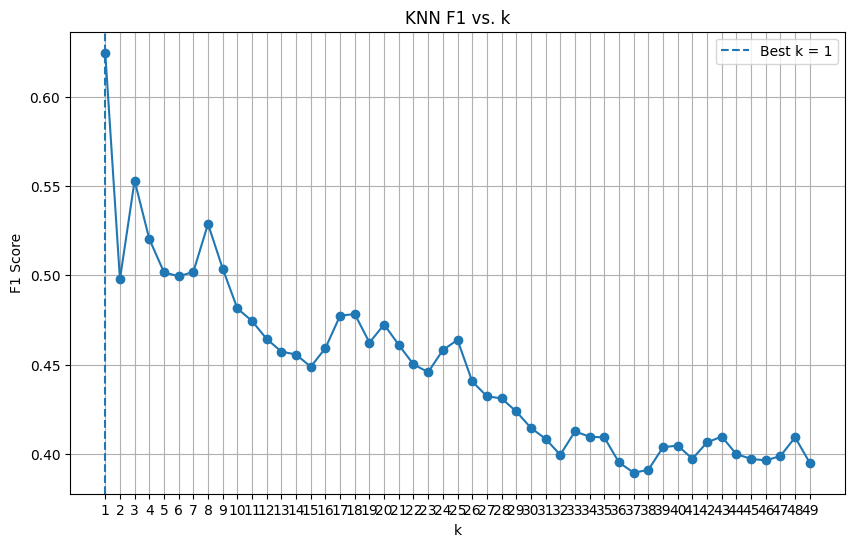

Best k: 1
Best f1_score: 0.6245


In [ ]:

from minilearn.classifiers import KNeighborsClassifier
from minilearn.metrics import f1_score
from minilearn.preprocessing import StandardScaler, train_test_split

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different k values
k_values = range(1, 50)
f1_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict(X_test_scaled)

    f1_scores.append(f1_score(y_test, y_proba))

# Find best k
best_f1_score = max(f1_scores)
best_k = k_values[f1_scores.index(best_f1_score)]

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("KNN F1 vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best f1_score: {best_f1_score:.4f}")

Once again, we can see minilearn performing just as well as sklearn!

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# baseline model

classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6334012219959266
Precision: 0.6268304959829618
Recall: 0.6346255060728745
Macro F1: 0.6245468939017281
Log Loss 13.213559287252721
[[49  0  1  8 10  0  2  5]
 [ 1 51  0  1  5 10  7  0]
 [ 4  0 15  4  4  0  3  9]
 [ 4  3  2 47 10  2  4  3]
 [ 4  6  2  6 49  4  1  3]
 [ 0  4  0  0  0 29  4  1]
 [ 0 13  6  8  3  4 41  0]
 [ 2  2  1  1  2  0  1 30]]


In the end, it looks like KNN is just about as effective as logistic regression. Though, one difference is that the model has a MUCH higher log loss. This tells us that the model is very confident about being wrong.

In [18]:
# Predicting emotion from features
from sklearn.naive_bayes import GaussianNB

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = GaussianNB()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2606924643584521
Precision: 0.3005289477262564
Recall: 0.2853475033738192
Macro F1: 0.24791296603480711
Log Loss 25.36777194062212
[[28  3  0 12 11  6  8  7]
 [ 0 14  2  0  3 48  7  1]
 [ 1  8  6  0  2 13  6  3]
 [ 8  9  4  6 19 14 12  3]
 [ 7  6  2  4 21 16 14  5]
 [ 0  1  0  0  0 33  3  1]
 [ 0  6  1  0  1 49 14  4]
 [ 2  6  3  1  1 16  4  6]]


GNB is spectacularly bad here! It's worse than random. This is mainly because it breaks GNB's assumptions of conditionally independent features and normally ditributed features within each class.

In [ ]:
# minilearn
from minilearn.classifiers import GaussianNaiveBayes
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.preprocessing import StandardScaler, train_test_split

# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = GaussianNaiveBayes()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2606924643584521
Precision: 0.3005289477262564
Recall: 0.2853475033738192
Macro F1: 0.24791296603480711
[[28  3  0 12 11  6  8  7]
 [ 0 14  2  0  3 48  7  1]
 [ 1  8  6  0  2 13  6  3]
 [ 8  9  4  6 19 14 12  3]
 [ 7  6  2  4 21 16 14  5]
 [ 0  1  0  0  0 33  3  1]
 [ 0  6  1  0  1 49 14  4]
 [ 2  6  3  1  1 16  4  6]]


At least minilearn performs equally poorly!

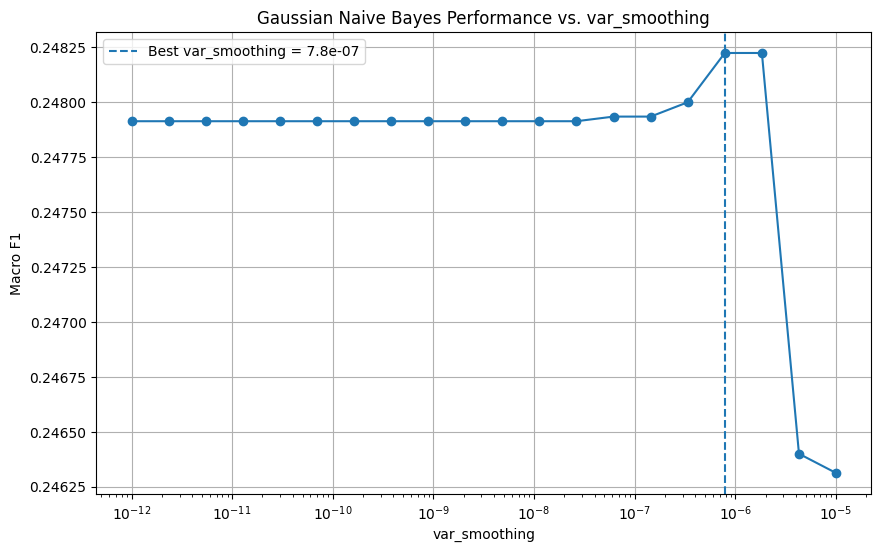

Best var_smoothing: 7.8e-07
Best Macro F1: 0.2482


In [ ]:
# sklearn
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

var_values = np.logspace(-12, -5, 20)
f1_scores = []

for var in var_values:
    classifier = GaussianNB(var_smoothing=var)
    classifier.fit(X_train_scaled, y_train)

    y_pred = classifier.predict(X_test_scaled)

    f1_scores.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

best_var = var_values[f1_scores.index(max(f1_scores))]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 6))
plt.semilogx(var_values, f1_scores, marker="o")
plt.axvline(best_var, linestyle="--", label=f"Best var_smoothing = {best_var:.1e}")

plt.xlabel("var_smoothing")
plt.ylabel("Macro F1")
plt.title("Gaussian Naive Bayes Performance vs. var_smoothing")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best var_smoothing: {best_var:.1e}")
print(f"Best Macro F1: {best_f1:.4f}")

Turns out tweaking hyperparameters doesn't make any meaningful difference when assumptions are violated.